# Processing time courses.

In [1]:
from pathlib import Path
import numpy as np
current_dir = Path().resolve()
from microlive.imports import *
from microlive import microscopy as mi
from pipeline_time_courses import (
    compute_autocorrelation_for_dataset,
    compute_cross_correlation_for_dataset,
    analyze_crosscorr,
    analyze_dual_channel_time_courses,
    run_simulation_and_generate_data,
    plot_dual_channel_kymograph,
)

In [2]:
#data_folder = Path('/Users/nzlab-la/Desktop/processing_GFPsf')

data_folder = Path('/Volumes/Luis_DRIVE/CoF Manuscript LIFs/CoF_long_movies/sfGFP/results')
results_folder = data_folder.joinpath('temp_processing')
results_folder.mkdir(exist_ok=True) 
plot_name = data_folder.name + '_ACF.svg'
plot_name

'results_ACF.svg'

In [3]:
# Parameters
step_size_in_sec = 5
start_lag = 1
selected_field = 'spot_int_ch_' #'spot_int_ch_' #'spot_int_ch_'  # spot_int_ch_0, psf_amplitude_ch_, snr_ch_, total_spot_int_ch_
min_percentage_data_in_trajectory = 0.3
max_missing_frames = 3
downsample = False
downsampling_factor = 3
control_spots_mode = False
use_global_mean = False
dataset_name = 'cof'
y_axes_min_max_list_values =  [-0.02, 0.04]
x_axes_min_max_list_values = [-10, 400]
max_lag = 300
if control_spots_mode:
    y_axes_min_max_list_values = None # [-20, 20]
MAD_THRESHOLD_FACTOR = 6 # 6 was working well for the control spots. 
multi_tau_raw_points = 40
multi_tau_bins_per_stage = 20
min_snr = 0.5 # 1 #0.5
smooth_window = 1
color_green = (0.0, 1.0, 0.0)  # No Red, Full Green, No Blue
color_magenta = (1.0, 0.0, 1.0)  # Full Red, No Green, Full Blue

line_color = (1.0, 0.0, 1.0)  # Full Red, No Green, Full Blue
line_color_fit = 'dimgray' # No Red, Full Green, No Blue
remove_outliers = True
correct_baseline = True

# parameters to evaluate
multi_tau=True
detrend = False  # detrend removed from Correlation class; correct_baseline=True handles residual drift



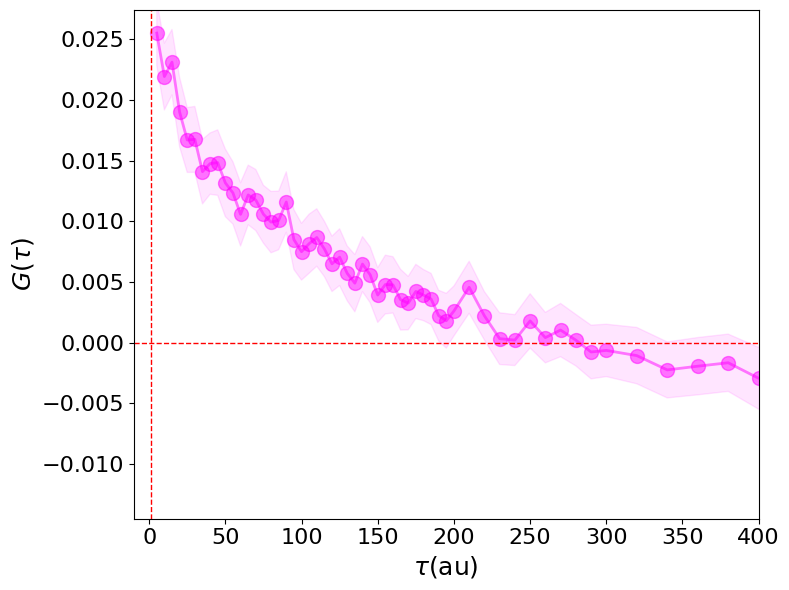

Number of trajectories: 73
Number of cells (post-filter): 14


In [4]:
results = compute_autocorrelation_for_dataset(
    dataset=dataset_name,
    data_folder=data_folder,
    results_folder=results_folder,
    selected_field=selected_field,
    channel_index=1,
    step_size_in_sec=step_size_in_sec,
    start_lag=start_lag,
    min_percentage_data_in_trajectory=min_percentage_data_in_trajectory,
    max_missing_frames=max_missing_frames,
    downsample=downsample,
    downsampling_factor=downsampling_factor,
    use_global_mean=use_global_mean,
    control_spots_mode=control_spots_mode,
    correct_baseline=correct_baseline,  # correct_baseline,
    min_snr=min_snr,
    smooth_window=smooth_window,
    remove_outliers=remove_outliers,  # remove_outliers,
    MAD_THRESHOLD_FACTOR=MAD_THRESHOLD_FACTOR,
    multi_tau=multi_tau,
    multi_tau_raw_points=multi_tau_raw_points,
    multi_tau_bins_per_stage=multi_tau_bins_per_stage,
    x_axes_min_max_list_values=x_axes_min_max_list_values,
    max_lag = max_lag,
    index_max_lag_for_fit = None,
    fit_type='linear',
    de_correlation_threshold=-0.002,
    use_linear_projection_for_lag_0 = True,
    verbose=False,
    simulation_mode=False,
    SSA_data=None,
    line_color=line_color,
    line_color_fit=line_color_fit,
    plot_name= plot_name,
    save_plots= False,
    #figsize=(3.2,2.2),
)

In [5]:
dwell_time = results['dwell_time']
G0 = results['mean_correlation'][0]  # G(tau=0); index 0 after return_full=False strips negative lags
gene_length = 1826
ke = gene_length / dwell_time
ki = 1 / (G0 * dwell_time)  # Larson et al. 2011: ki = 1/(G(0)*tau_c)


In [6]:
# ribosomal density calculation
def calculate_ribosomal_density(ki, ke, ribosomal_footprint=10):
    ribosomal_density= (ki * ribosomal_footprint) / ke
    ribosomal_density = ribosomal_density * 100
    return np.round(ribosomal_density, 3)

def calculate_number_ribosomes_RNA(ki, ke, gene_length):
    number_ribosomes = (ki * gene_length) / ke
    return np.round(number_ribosomes, 3)

def calculate_ribosomal_distance(gene_length, number_ribosomes):
    ribosomal_distance = gene_length / number_ribosomes
    return np.round(ribosomal_distance, 3)

ribosomal_density = calculate_ribosomal_density(ki, ke)
number_ribosomes = calculate_number_ribosomes_RNA(ki, ke, gene_length)
ribosomal_distance = calculate_ribosomal_distance(gene_length, number_ribosomes)

ki_rounded = np.round(ki, 4)
ke_rounded = np.round(ke, 4)


# metrics to evaluate
print(f"Data: {data_folder.stem.replace('processing_', ''):<15} ki: {ki_rounded:<8} ke: {ke_rounded:<8} length: {gene_length:<5} rib_density: {ribosomal_density:<8} no_rib: {number_ribosomes:<8} rib_dist: {ribosomal_distance:<8}" )

Data: results         ki: nan      ke: nan      length: 1826  rib_density: nan      no_rib: nan      rib_dist: nan     
